Load all preprocessed arrays

In [1]:
import joblib
import numpy as np

# Load all preprocessed data in one line
data = joblib.load('fyp_preprocessed_data.pkl')

# 80/20 split
X_train_80_lr_bal   = data['X_train_80_lr']
X_train_80_tree_bal = data['X_train_80_tree']
X_test_80_lr        = data['X_test_80_lr']
X_test_80_tree      = data['X_test_80_tree']
y_train_80_bal      = data['y_train_80']
y_test_80           = data['y_test_80']

# 70/30 split
X_train_70_lr_bal   = data['X_train_70_lr']
X_train_70_tree_bal = data['X_train_70_tree']
X_test_70_lr        = data['X_test_70_lr']
X_test_70_tree      = data['X_test_70_tree']
y_train_70_bal      = data['y_train_70']
y_test_70           = data['y_test_70']

# Preprocessors (for later — dashboard)
preprocessor_lr      = data['preprocessor_lr']
preprocessor_tree    = data['preprocessor_tree']
preprocessor_lr_70   = data['preprocessor_lr_70']
preprocessor_tree_70 = data['preprocessor_tree_70']

print("All data loaded successfully.")
print(f"  X_train_80_tree_bal : {X_train_80_tree_bal.shape}")
print(f"  X_train_70_tree_bal : {X_train_70_tree_bal.shape}")
print(f"  X_train_80_lr_bal   : {X_train_80_lr_bal.shape}")
print(f"  X_train_70_lr_bal   : {X_train_70_lr_bal.shape}")

All data loaded successfully.
  X_train_80_tree_bal : (190902, 12)
  X_train_70_tree_bal : (167040, 12)
  X_train_80_lr_bal   : (190902, 85)
  X_train_70_lr_bal   : (167040, 85)


1.Random Forest

In [2]:
# Evaluation helper function (define once, reuse for all models)
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)

def evaluate_model(model, X_test, y_test, model_name, split_label):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_wt   = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba[:, 1])
    cm      = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"  {model_name} — {split_label}")
    print(f"{'='*60}")
    print(f"  Accuracy         : {acc:.4f}")
    print(f"  F1 (macro)       : {f1_mac:.4f}")
    print(f"  F1 (weighted)    : {f1_wt:.4f}")
    print(f"  ROC-AUC (binary) : {roc_auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'At Risk']))

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'At Risk'],
                yticklabels=['Low Risk', 'At Risk'])
    plt.title(f'Confusion Matrix — {model_name} ({split_label})', fontsize=12)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f"cm_{model_name.replace(' ','_')}_{split_label.replace('/','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Confusion matrix saved → {fname}")

    return {
        'Model'       : model_name,
        'Split'       : split_label,
        'Accuracy'    : round(acc,    4),
        'F1_macro'    : round(f1_mac, 4),
        'F1_weighted' : round(f1_wt,  4),
        'ROC_AUC'     : round(roc_auc,4)
    }

# Shared results list — every model appends here
results = []
print("Evaluation function defined. Results list initialised.")

Evaluation function defined. Results list initialised.


In [3]:
# ── Train Random Forest — 80/20 ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf_80 = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

print("Training Random Forest (80/20)...")
rf_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Random Forest (80/20)...
Done.


In [4]:
# Train Random Forest — 70/30 
rf_70 = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

print("Training Random Forest (70/30)...")
rf_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Random Forest (70/30)...
Done.



  Random Forest — 80/20
  Accuracy         : 0.7283
  F1 (macro)       : 0.6288
  F1 (weighted)    : 0.7168
  ROC-AUC (binary) : 0.6829

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.85      0.82     23864
     At Risk       0.50      0.39      0.44      8872

    accuracy                           0.73     32736
   macro avg       0.64      0.62      0.63     32736
weighted avg       0.71      0.73      0.72     32736



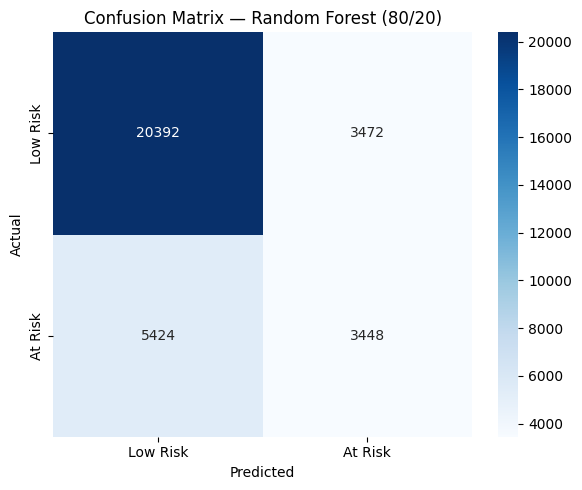

  Confusion matrix saved → cm_Random_Forest_80_20.png

  Random Forest — 70/30
  Accuracy         : 0.7269
  F1 (macro)       : 0.6273
  F1 (weighted)    : 0.7156
  ROC-AUC (binary) : 0.6839

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.85      0.82     35795
     At Risk       0.50      0.39      0.43     13308

    accuracy                           0.73     49103
   macro avg       0.64      0.62      0.63     49103
weighted avg       0.71      0.73      0.72     49103



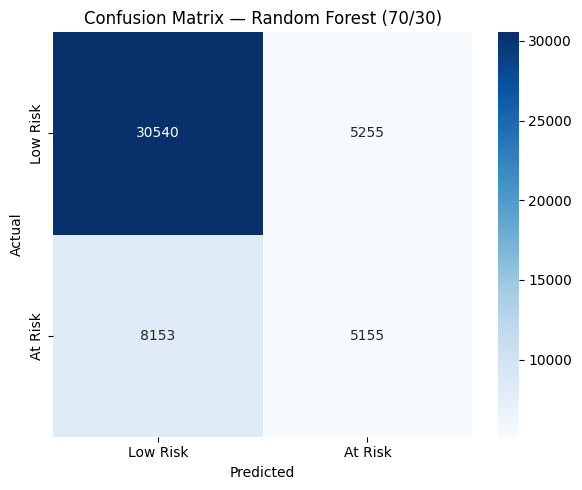

  Confusion matrix saved → cm_Random_Forest_70_30.png


In [5]:
#  Evaluate Random Forest — both splits
res_rf_80 = evaluate_model(rf_80, X_test_80_tree, y_test_80,
                            'Random Forest', '80/20')
res_rf_70 = evaluate_model(rf_70, X_test_70_tree, y_test_70,
                            'Random Forest', '70/30')

results.append(res_rf_80)
results.append(res_rf_70)

In [6]:
# ── Hyperparameter Tuning — Random Forest (80/20) ────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced']
}

rf_search_80 = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 15,          # 15 random combinations
    cv                  = 3,           # 3-fold cross-validation
    scoring             = 'f1_macro',  # fair across imbalanced classes
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning Random Forest (80/20)... this may take several minutes.\n")
rf_search_80.fit(X_train_80_tree_bal, y_train_80_bal)

rf_tuned_80 = rf_search_80.best_estimator_

print(f"\nBest parameters (80/20):")
for p, v in rf_search_80.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {rf_search_80.best_score_:.4f}")

Tuning Random Forest (80/20)... this may take several minutes.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  n_estimators         : 200
  min_samples_split    : 2
  min_samples_leaf     : 1
  max_features         : log2
  max_depth            : 30
  class_weight         : balanced

Best CV F1-macro : 0.7801


In [7]:
# Hyperparameter Tuning — Random Forest (70/30)
rf_search_70 = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'f1_macro',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning Random Forest (70/30)... this may take several minutes.\n")
rf_search_70.fit(X_train_70_tree_bal, y_train_70_bal)

rf_tuned_70 = rf_search_70.best_estimator_

print(f"\nBest parameters (70/30):")
for p, v in rf_search_70.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {rf_search_70.best_score_:.4f}")

Tuning Random Forest (70/30)... this may take several minutes.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  n_estimators         : 200
  min_samples_split    : 2
  min_samples_leaf     : 1
  max_features         : log2
  max_depth            : 30
  class_weight         : balanced

Best CV F1-macro : 0.7824



  Random Forest Tuned — 80/20
  Accuracy         : 0.7307
  F1 (macro)       : 0.6410
  F1 (weighted)    : 0.7232
  ROC-AUC (binary) : 0.7036

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.84      0.82     23864
     At Risk       0.50      0.43      0.46      8872

    accuracy                           0.73     32736
   macro avg       0.65      0.63      0.64     32736
weighted avg       0.72      0.73      0.72     32736



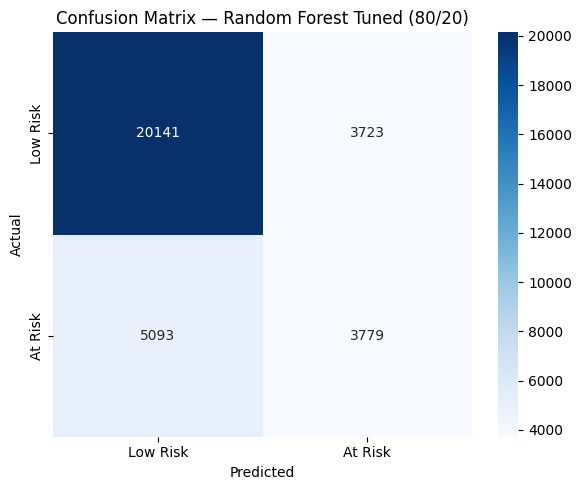

  Confusion matrix saved → cm_Random_Forest_Tuned_80_20.png

  Random Forest Tuned — 70/30
  Accuracy         : 0.7289
  F1 (macro)       : 0.6391
  F1 (weighted)    : 0.7216
  ROC-AUC (binary) : 0.7030

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.84      0.82     35795
     At Risk       0.50      0.42      0.46     13308

    accuracy                           0.73     49103
   macro avg       0.65      0.63      0.64     49103
weighted avg       0.72      0.73      0.72     49103



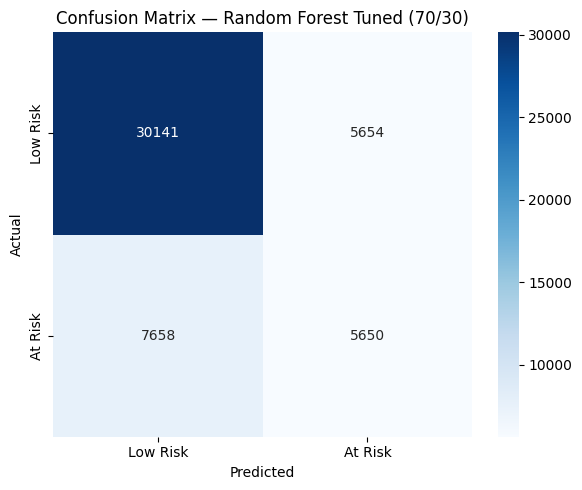

  Confusion matrix saved → cm_Random_Forest_Tuned_70_30.png


In [8]:
# Evaluate tuned Random Forest — both splits
res_rf_tuned_80 = evaluate_model(rf_tuned_80, X_test_80_tree, y_test_80,
                                  'Random Forest Tuned', '80/20')
res_rf_tuned_70 = evaluate_model(rf_tuned_70, X_test_70_tree, y_test_70,
                                  'Random Forest Tuned', '70/30')

results.append(res_rf_tuned_80)
results.append(res_rf_tuned_70)

In [9]:
# Random Forest Models — Comparison Summary
import pandas as pd

rf_comparison = pd.DataFrame([
    res_rf_80,        # baseline 80/20
    res_rf_70,        # baseline 70/30
    res_rf_tuned_80,  # tuned 80/20
    res_rf_tuned_70   # tuned 70/30
])

print("Random Forest — Baseline vs Tuned Comparison")
print("=" * 70)
print(rf_comparison.to_string(index=False))

Random Forest — Baseline vs Tuned Comparison
              Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Random Forest 80/20    0.7283    0.6288       0.7168   0.6829
      Random Forest 70/30    0.7269    0.6273       0.7156   0.6839
Random Forest Tuned 80/20    0.7307    0.6410       0.7232   0.7036
Random Forest Tuned 70/30    0.7289    0.6391       0.7216   0.7030


2.xgboost

In [10]:
# Train XGBoost — 80/20
from xgboost import XGBClassifier

xgb_80 = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.3,
    objective        = 'binary:logistic',
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)

print("Training XGBoost (80/20)...")
xgb_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training XGBoost (80/20)...
Done.


In [11]:
# Train XGBoost — 70/30
xgb_70 = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.3,
    objective        = 'binary:logistic',
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)

print("Training XGBoost (70/30)...")
xgb_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training XGBoost (70/30)...
Done.



  XGBoost — 80/20
  Accuracy         : 0.7786
  F1 (macro)       : 0.6421
  F1 (weighted)    : 0.7433
  ROC-AUC (binary) : 0.7359

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     23864
     At Risk       0.72      0.30      0.42      8872

    accuracy                           0.78     32736
   macro avg       0.75      0.63      0.64     32736
weighted avg       0.77      0.78      0.74     32736



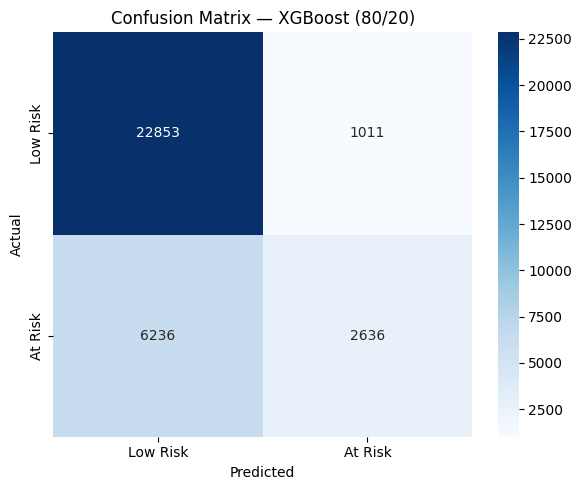

  Confusion matrix saved → cm_XGBoost_80_20.png

  XGBoost — 70/30
  Accuracy         : 0.7780
  F1 (macro)       : 0.6428
  F1 (weighted)    : 0.7435
  ROC-AUC (binary) : 0.7359

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     35795
     At Risk       0.72      0.30      0.42     13308

    accuracy                           0.78     49103
   macro avg       0.75      0.63      0.64     49103
weighted avg       0.77      0.78      0.74     49103



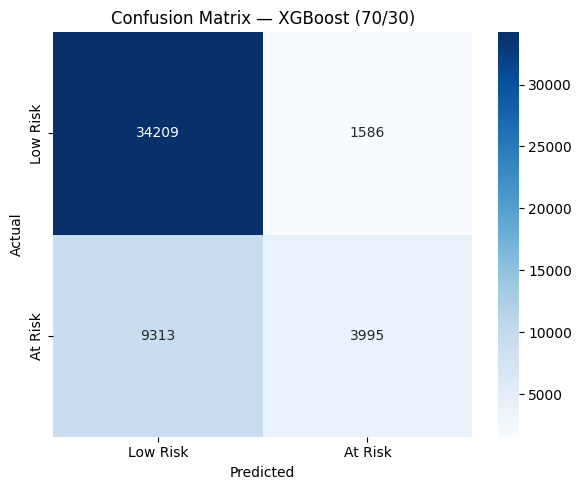

  Confusion matrix saved → cm_XGBoost_70_30.png


In [12]:
# Evaluate XGBoost — both splits 
res_xgb_80 = evaluate_model(xgb_80, X_test_80_tree, y_test_80,
                             'XGBoost', '80/20')
res_xgb_70 = evaluate_model(xgb_70, X_test_70_tree, y_test_70,
                             'XGBoost', '70/30')

results.append(res_xgb_80)
results.append(res_xgb_70)

In [13]:
# Hyperparameter Tuning — XGBoost (80/20)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist_xgb = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 6, 9],
    'learning_rate'    : [0.01, 0.1, 0.3],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'gamma'            : [0, 0.1, 0.3]
}

xgb_search_80 = RandomizedSearchCV(
    estimator           = XGBClassifier(objective='binary:logistic',
                                        eval_metric='logloss',
                                        random_state=42, n_jobs=-1),
    param_distributions = param_dist_xgb,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'f1_macro',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning XGBoost (80/20)... this may take several minutes.\n")
xgb_search_80.fit(X_train_80_tree_bal, y_train_80_bal)

xgb_tuned_80 = xgb_search_80.best_estimator_

print(f"\nBest parameters (80/20):")
for p, v in xgb_search_80.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {xgb_search_80.best_score_:.4f}")

Tuning XGBoost (80/20)... this may take several minutes.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  subsample            : 1.0
  n_estimators         : 300
  max_depth            : 6
  learning_rate        : 0.1
  gamma                : 0.3
  colsample_bytree     : 0.8

Best CV F1-macro : 0.7548


In [14]:
#  Hyperparameter Tuning — XGBoost (70/30)
xgb_search_70 = RandomizedSearchCV(
    estimator           = XGBClassifier(objective='binary:logistic',
                                        eval_metric='logloss',
                                        random_state=42, n_jobs=-1),
    param_distributions = param_dist_xgb,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'f1_macro',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning XGBoost (70/30)... this may take several minutes.\n")
xgb_search_70.fit(X_train_70_tree_bal, y_train_70_bal)

xgb_tuned_70 = xgb_search_70.best_estimator_

print(f"\nBest parameters (70/30):")
for p, v in xgb_search_70.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {xgb_search_70.best_score_:.4f}")

Tuning XGBoost (70/30)... this may take several minutes.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  subsample            : 1.0
  n_estimators         : 300
  max_depth            : 6
  learning_rate        : 0.1
  gamma                : 0.3
  colsample_bytree     : 0.8

Best CV F1-macro : 0.7564



  XGBoost Tuned — 80/20
  Accuracy         : 0.7792
  F1 (macro)       : 0.6439
  F1 (weighted)    : 0.7444
  ROC-AUC (binary) : 0.7385

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     23864
     At Risk       0.72      0.30      0.42      8872

    accuracy                           0.78     32736
   macro avg       0.75      0.63      0.64     32736
weighted avg       0.77      0.78      0.74     32736



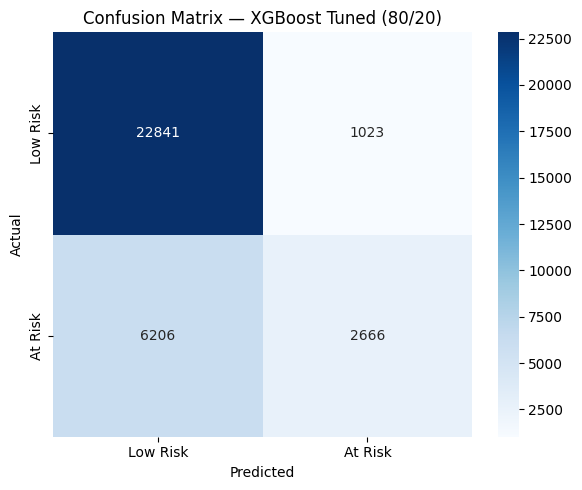

  Confusion matrix saved → cm_XGBoost_Tuned_80_20.png

  XGBoost Tuned — 70/30
  Accuracy         : 0.7803
  F1 (macro)       : 0.6446
  F1 (weighted)    : 0.7452
  ROC-AUC (binary) : 0.7380

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     35795
     At Risk       0.73      0.30      0.42     13308

    accuracy                           0.78     49103
   macro avg       0.76      0.63      0.64     49103
weighted avg       0.77      0.78      0.75     49103



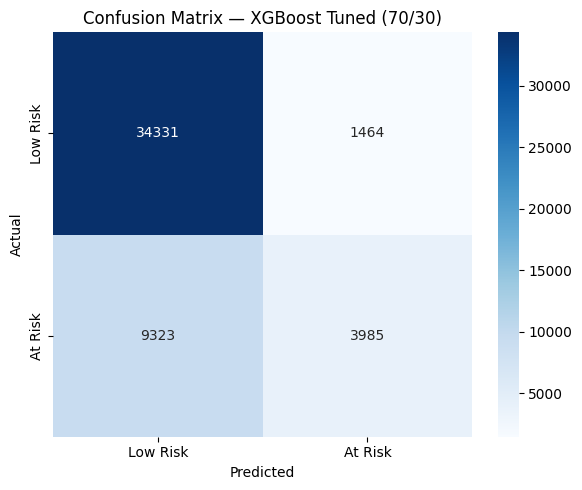

  Confusion matrix saved → cm_XGBoost_Tuned_70_30.png


In [15]:
# Evaluate tuned XGBoost — both splits
res_xgb_tuned_80 = evaluate_model(xgb_tuned_80, X_test_80_tree, y_test_80,
                                   'XGBoost Tuned', '80/20')
res_xgb_tuned_70 = evaluate_model(xgb_tuned_70, X_test_70_tree, y_test_70,
                                   'XGBoost Tuned', '70/30')

results.append(res_xgb_tuned_80)
results.append(res_xgb_tuned_70)

In [16]:
# Compare baseline vs tuned XGBoost
import pandas as pd

xgb_comparison = pd.DataFrame([
    res_xgb_80,         # baseline 80/20
    res_xgb_70,         # baseline 70/30
    res_xgb_tuned_80,   # tuned 80/20
    res_xgb_tuned_70    # tuned 70/30
])

print("XGBoost — Baseline vs Tuned Comparison")
print("=" * 70)
print(xgb_comparison.to_string(index=False))

XGBoost — Baseline vs Tuned Comparison
        Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      XGBoost 80/20    0.7786    0.6421       0.7433   0.7359
      XGBoost 70/30    0.7780    0.6428       0.7435   0.7359
XGBoost Tuned 80/20    0.7792    0.6439       0.7444   0.7385
XGBoost Tuned 70/30    0.7803    0.6446       0.7452   0.7380


3. Logistic Regression

In [17]:
# Train Logistic Regression — 80/20
from sklearn.linear_model import LogisticRegression

lr_80 = LogisticRegression(class_weight='balanced',
                            solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)

print("Training Logistic Regression (80/20)...")
lr_80.fit(X_train_80_lr_bal, y_train_80_bal)
print("Done.")

Training Logistic Regression (80/20)...


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done.


In [18]:
# Train Logistic Regression — 70/30
lr_70 = LogisticRegression(class_weight='balanced',
                            solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)

print("Training Logistic Regression (70/30)...")
lr_70.fit(X_train_70_lr_bal, y_train_70_bal)
print("Done.")

Training Logistic Regression (70/30)...


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done.



  Logistic Regression — 80/20
  Accuracy         : 0.6616
  F1 (macro)       : 0.6275
  F1 (weighted)    : 0.6791
  ROC-AUC (binary) : 0.7336

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     23864
     At Risk       0.42      0.66      0.51      8872

    accuracy                           0.66     32736
   macro avg       0.63      0.66      0.63     32736
weighted avg       0.73      0.66      0.68     32736



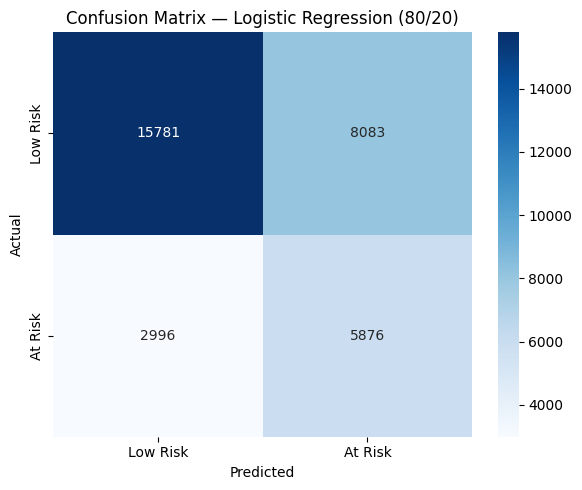

  Confusion matrix saved → cm_Logistic_Regression_80_20.png

  Logistic Regression — 70/30
  Accuracy         : 0.6614
  F1 (macro)       : 0.6266
  F1 (weighted)    : 0.6788
  ROC-AUC (binary) : 0.7334

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     35795
     At Risk       0.42      0.66      0.51     13308

    accuracy                           0.66     49103
   macro avg       0.63      0.66      0.63     49103
weighted avg       0.73      0.66      0.68     49103



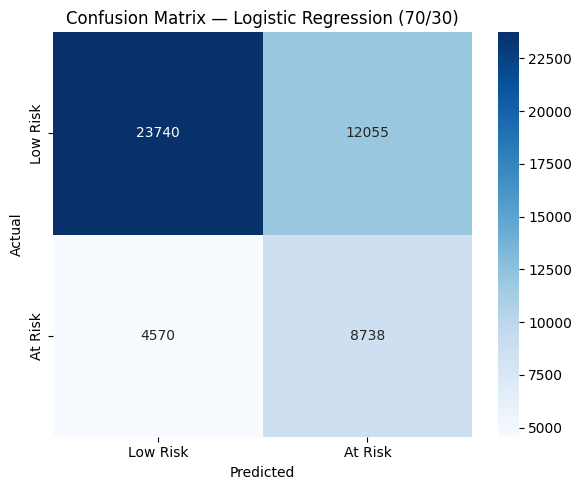

  Confusion matrix saved → cm_Logistic_Regression_70_30.png


In [19]:
# Evaluate Logistic Regression — both splits
res_lr_80 = evaluate_model(lr_80, X_test_80_lr, y_test_80, 'Logistic Regression', '80/20')
res_lr_70 = evaluate_model(lr_70, X_test_70_lr, y_test_70, 'Logistic Regression', '70/30')
results.append(res_lr_80)
results.append(res_lr_70)

In [20]:
# Hyperparameter Tuning — Logistic Regression (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

param_dist_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000],
    'class_weight': ['balanced']
}

lr_search_80 = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42, n_jobs=-1),
    param_distributions=param_dist_lr, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Logistic Regression (80/20)...\n")
lr_search_80.fit(X_train_80_lr_bal, y_train_80_bal)
lr_tuned_80 = lr_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in lr_search_80.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {lr_search_80.best_score_:.4f}")

Tuning Logistic Regression (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best parameters (80/20):
  solver               : saga
  max_iter             : 1000
  class_weight         : balanced
  C                    : 1

Best CV F1-macro : 0.6374


In [21]:
# Hyperparameter Tuning — Logistic Regression (70/30)
lr_search_70 = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42, n_jobs=-1),
    param_distributions=param_dist_lr, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Logistic Regression (70/30)...\n")
lr_search_70.fit(X_train_70_lr_bal, y_train_70_bal)
lr_tuned_70 = lr_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in lr_search_70.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {lr_search_70.best_score_:.4f}")

Tuning Logistic Regression (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best parameters (70/30):
  solver               : saga
  max_iter             : 500
  class_weight         : balanced
  C                    : 0.1

Best CV F1-macro : 0.6399



  Logistic Regression Tuned — 80/20
  Accuracy         : 0.6612
  F1 (macro)       : 0.6270
  F1 (weighted)    : 0.6787
  ROC-AUC (binary) : 0.7339

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     23864
     At Risk       0.42      0.66      0.51      8872

    accuracy                           0.66     32736
   macro avg       0.63      0.66      0.63     32736
weighted avg       0.73      0.66      0.68     32736



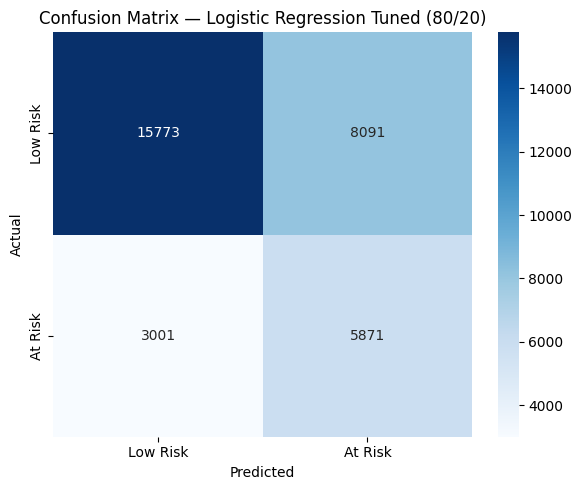

  Confusion matrix saved → cm_Logistic_Regression_Tuned_80_20.png

  Logistic Regression Tuned — 70/30
  Accuracy         : 0.6615
  F1 (macro)       : 0.6266
  F1 (weighted)    : 0.6789
  ROC-AUC (binary) : 0.7335

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     35795
     At Risk       0.42      0.66      0.51     13308

    accuracy                           0.66     49103
   macro avg       0.63      0.66      0.63     49103
weighted avg       0.73      0.66      0.68     49103



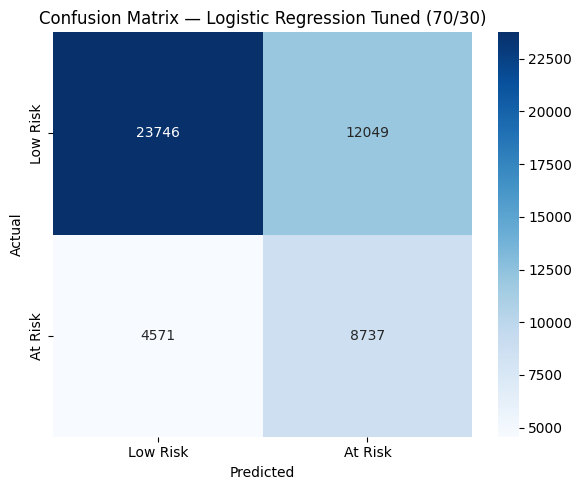

  Confusion matrix saved → cm_Logistic_Regression_Tuned_70_30.png


In [22]:
# Evaluate tuned Logistic Regression — both splits
res_lr_tuned_80 = evaluate_model(lr_tuned_80, X_test_80_lr, y_test_80, 'Logistic Regression Tuned', '80/20')
res_lr_tuned_70 = evaluate_model(lr_tuned_70, X_test_70_lr, y_test_70, 'Logistic Regression Tuned', '70/30')
results.append(res_lr_tuned_80)
results.append(res_lr_tuned_70)

In [23]:
# Logistic Regression — Baseline vs Tuned Comparison
import pandas as pd
lr_comparison = pd.DataFrame([res_lr_80, res_lr_70, res_lr_tuned_80, res_lr_tuned_70])
print("Logistic Regression — Baseline vs Tuned Comparison")
print("=" * 70)
print(lr_comparison.to_string(index=False))

Logistic Regression — Baseline vs Tuned Comparison
                    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Logistic Regression 80/20    0.6616    0.6275       0.6791   0.7336
      Logistic Regression 70/30    0.6614    0.6266       0.6788   0.7334
Logistic Regression Tuned 80/20    0.6612    0.6270       0.6787   0.7339
Logistic Regression Tuned 70/30    0.6615    0.6266       0.6789   0.7335


4. SVM (Support Vector Machine)

In [24]:
# Train SVM — 80/20  (LinearSVC + CalibratedClassifierCV for predict_proba)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_80 = CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42), cv=3)
print("Training SVM (80/20)...")
svm_80.fit(X_train_80_lr_bal, y_train_80_bal)
print("Done.")

Training SVM (80/20)...
Done.


In [25]:
# Train SVM — 70/30
svm_70 = CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42), cv=3)
print("Training SVM (70/30)...")
svm_70.fit(X_train_70_lr_bal, y_train_70_bal)
print("Done.")

Training SVM (70/30)...
Done.



  SVM — 80/20
  Accuracy         : 0.6616
  F1 (macro)       : 0.6273
  F1 (weighted)    : 0.6791
  ROC-AUC (binary) : 0.7333

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     23864
     At Risk       0.42      0.66      0.51      8872

    accuracy                           0.66     32736
   macro avg       0.63      0.66      0.63     32736
weighted avg       0.73      0.66      0.68     32736



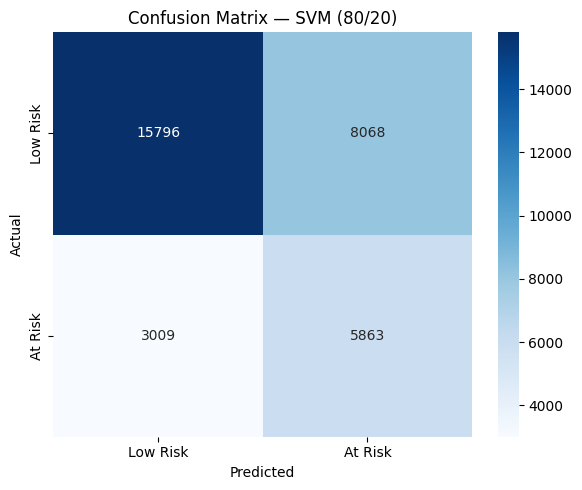

  Confusion matrix saved → cm_SVM_80_20.png

  SVM — 70/30
  Accuracy         : 0.6615
  F1 (macro)       : 0.6263
  F1 (weighted)    : 0.6788
  ROC-AUC (binary) : 0.7330

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     35795
     At Risk       0.42      0.65      0.51     13308

    accuracy                           0.66     49103
   macro avg       0.63      0.66      0.63     49103
weighted avg       0.72      0.66      0.68     49103



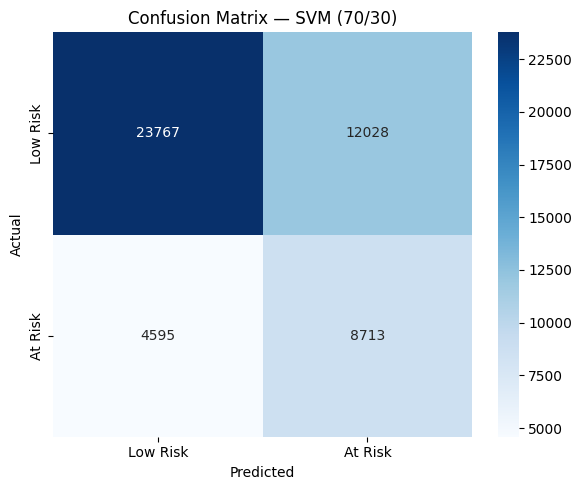

  Confusion matrix saved → cm_SVM_70_30.png


In [26]:
# Evaluate SVM — both splits
res_svm_80 = evaluate_model(svm_80, X_test_80_lr, y_test_80, 'SVM', '80/20')
res_svm_70 = evaluate_model(svm_70, X_test_70_lr, y_test_70, 'SVM', '70/30')
results.append(res_svm_80)
results.append(res_svm_70)

In [27]:
# Hyperparameter Tuning — SVM (80/20)
from sklearn.model_selection import RandomizedSearchCV

param_dist_svm = {
    'estimator__C'           : [0.01, 0.1, 1, 10],
    'estimator__max_iter'    : [1000, 2000],
    'estimator__class_weight': ['balanced']
}

svm_search_80 = RandomizedSearchCV(
    estimator=CalibratedClassifierCV(LinearSVC(random_state=42), cv=3),
    param_distributions=param_dist_svm, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning SVM (80/20)...\n")
svm_search_80.fit(X_train_80_lr_bal, y_train_80_bal)
svm_tuned_80 = svm_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in svm_search_80.best_params_.items():
    print(f"  {p:<30} : {v}")
print(f"\nBest CV F1-macro : {svm_search_80.best_score_:.4f}")

Tuning SVM (80/20)...

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best parameters (80/20):
  estimator__max_iter            : 1000
  estimator__class_weight        : balanced
  estimator__C                   : 0.1

Best CV F1-macro : 0.6380


In [28]:
# Hyperparameter Tuning — SVM (70/30)
svm_search_70 = RandomizedSearchCV(
    estimator=CalibratedClassifierCV(LinearSVC(random_state=42), cv=3),
    param_distributions=param_dist_svm, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning SVM (70/30)...\n")
svm_search_70.fit(X_train_70_lr_bal, y_train_70_bal)
svm_tuned_70 = svm_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in svm_search_70.best_params_.items():
    print(f"  {p:<30} : {v}")
print(f"\nBest CV F1-macro : {svm_search_70.best_score_:.4f}")

Tuning SVM (70/30)...

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best parameters (70/30):
  estimator__max_iter            : 1000
  estimator__class_weight        : balanced
  estimator__C                   : 0.1

Best CV F1-macro : 0.6407



  SVM Tuned — 80/20
  Accuracy         : 0.6619
  F1 (macro)       : 0.6275
  F1 (weighted)    : 0.6793
  ROC-AUC (binary) : 0.7334

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     23864
     At Risk       0.42      0.66      0.51      8872

    accuracy                           0.66     32736
   macro avg       0.63      0.66      0.63     32736
weighted avg       0.73      0.66      0.68     32736



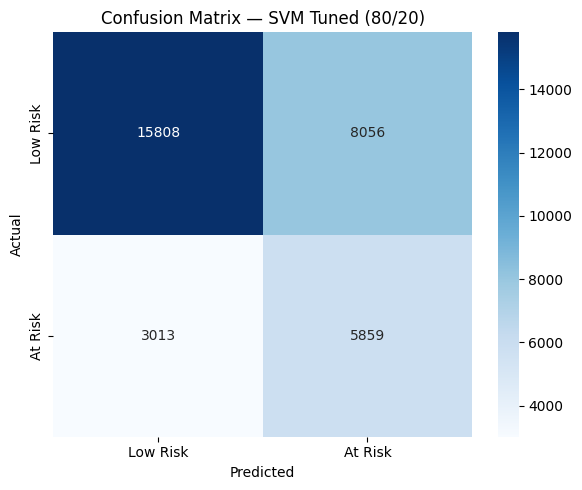

  Confusion matrix saved → cm_SVM_Tuned_80_20.png

  SVM Tuned — 70/30
  Accuracy         : 0.6619
  F1 (macro)       : 0.6268
  F1 (weighted)    : 0.6792
  ROC-AUC (binary) : 0.7330

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.66      0.74     35795
     At Risk       0.42      0.66      0.51     13308

    accuracy                           0.66     49103
   macro avg       0.63      0.66      0.63     49103
weighted avg       0.73      0.66      0.68     49103



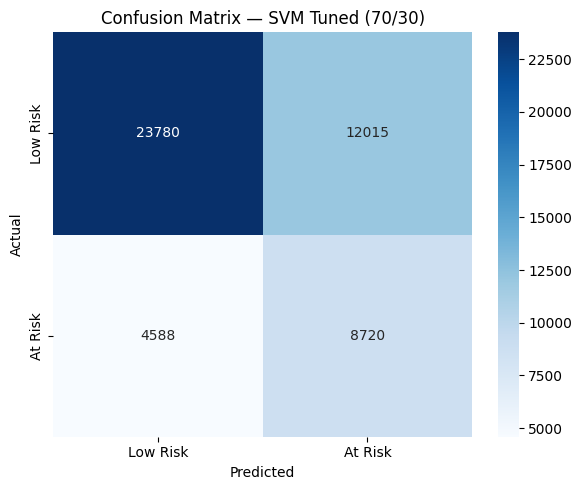

  Confusion matrix saved → cm_SVM_Tuned_70_30.png


In [29]:
# Evaluate tuned SVM — both splits
res_svm_tuned_80 = evaluate_model(svm_tuned_80, X_test_80_lr, y_test_80, 'SVM Tuned', '80/20')
res_svm_tuned_70 = evaluate_model(svm_tuned_70, X_test_70_lr, y_test_70, 'SVM Tuned', '70/30')
results.append(res_svm_tuned_80)
results.append(res_svm_tuned_70)

In [30]:
# SVM — Baseline vs Tuned Comparison
import pandas as pd
svm_comparison = pd.DataFrame([res_svm_80, res_svm_70, res_svm_tuned_80, res_svm_tuned_70])
print("SVM — Baseline vs Tuned Comparison")
print("=" * 70)
print(svm_comparison.to_string(index=False))

SVM — Baseline vs Tuned Comparison
    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      SVM 80/20    0.6616    0.6273       0.6791   0.7333
      SVM 70/30    0.6615    0.6263       0.6788   0.7330
SVM Tuned 80/20    0.6619    0.6275       0.6793   0.7334
SVM Tuned 70/30    0.6619    0.6268       0.6792   0.7330


5. Gradient Boosting

In [31]:
# Train Gradient Boosting — 80/20
from sklearn.ensemble import GradientBoostingClassifier

gb_80 = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
print("Training Gradient Boosting (80/20)...")
gb_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Gradient Boosting (80/20)...
Done.


In [32]:
# Train Gradient Boosting — 70/30
gb_70 = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
print("Training Gradient Boosting (70/30)...")
gb_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Gradient Boosting (70/30)...
Done.



  Gradient Boosting — 80/20
  Accuracy         : 0.7633
  F1 (macro)       : 0.6609
  F1 (weighted)    : 0.7463
  ROC-AUC (binary) : 0.7349

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.90      0.85     23864
     At Risk       0.60      0.39      0.47      8872

    accuracy                           0.76     32736
   macro avg       0.70      0.65      0.66     32736
weighted avg       0.74      0.76      0.75     32736



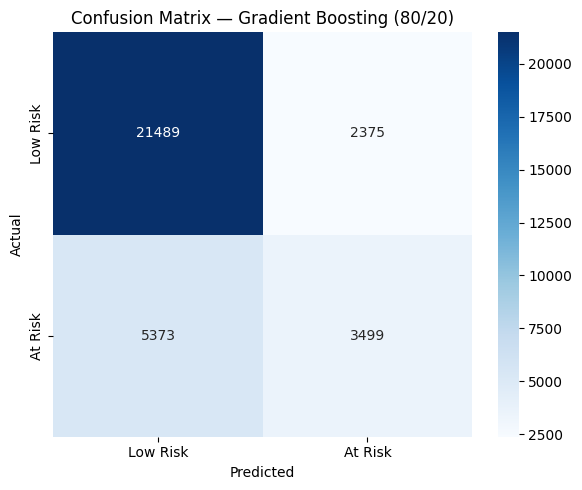

  Confusion matrix saved → cm_Gradient_Boosting_80_20.png

  Gradient Boosting — 70/30
  Accuracy         : 0.7672
  F1 (macro)       : 0.6608
  F1 (weighted)    : 0.7478
  ROC-AUC (binary) : 0.7356

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.91      0.85     35795
     At Risk       0.61      0.38      0.47     13308

    accuracy                           0.77     49103
   macro avg       0.71      0.65      0.66     49103
weighted avg       0.75      0.77      0.75     49103



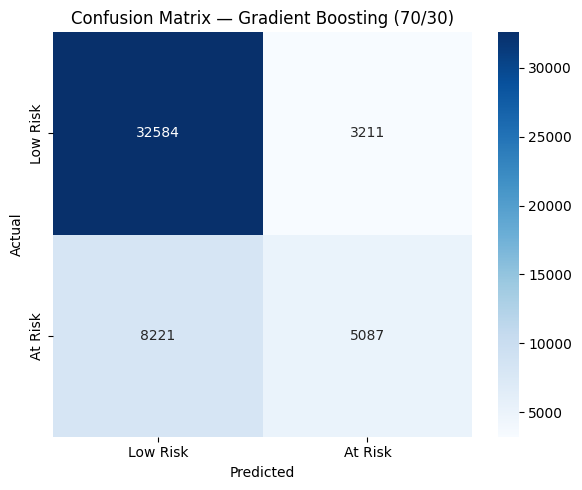

  Confusion matrix saved → cm_Gradient_Boosting_70_30.png


In [33]:
# Evaluate Gradient Boosting — both splits
res_gb_80 = evaluate_model(gb_80, X_test_80_tree, y_test_80, 'Gradient Boosting', '80/20')
res_gb_70 = evaluate_model(gb_70, X_test_70_tree, y_test_70, 'Gradient Boosting', '70/30')
results.append(res_gb_80)
results.append(res_gb_70)

In [34]:
# Hyperparameter Tuning — Gradient Boosting (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_dist_gb = {
    'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.8, 1.0], 'min_samples_split': [2, 5]
}

gb_search_80 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Gradient Boosting (80/20)...\n")
gb_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
gb_tuned_80 = gb_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in gb_search_80.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {gb_search_80.best_score_:.4f}")

Tuning Gradient Boosting (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  subsample              : 1.0
  n_estimators           : 300
  min_samples_split      : 2
  max_depth              : 3
  learning_rate          : 0.3

Best CV F1-macro : 0.7631


In [35]:
# Hyperparameter Tuning — Gradient Boosting (70/30)
gb_search_70 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Gradient Boosting (70/30)...\n")
gb_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
gb_tuned_70 = gb_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in gb_search_70.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {gb_search_70.best_score_:.4f}")

Tuning Gradient Boosting (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  subsample              : 1.0
  n_estimators           : 300
  min_samples_split      : 2
  max_depth              : 3
  learning_rate          : 0.3

Best CV F1-macro : 0.7643



  Gradient Boosting Tuned — 80/20
  Accuracy         : 0.7797
  F1 (macro)       : 0.6408
  F1 (weighted)    : 0.7431
  ROC-AUC (binary) : 0.7386

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.96      0.86     23864
     At Risk       0.74      0.29      0.42      8872

    accuracy                           0.78     32736
   macro avg       0.76      0.63      0.64     32736
weighted avg       0.77      0.78      0.74     32736



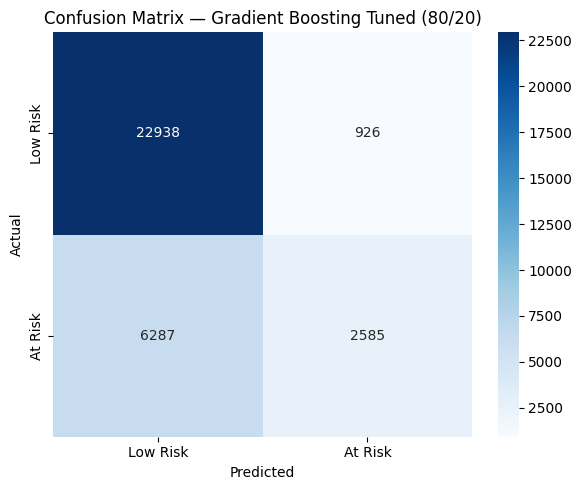

  Confusion matrix saved → cm_Gradient_Boosting_Tuned_80_20.png

  Gradient Boosting Tuned — 70/30
  Accuracy         : 0.7802
  F1 (macro)       : 0.6415
  F1 (weighted)    : 0.7436
  ROC-AUC (binary) : 0.7391

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     35795
     At Risk       0.74      0.29      0.42     13308

    accuracy                           0.78     49103
   macro avg       0.76      0.63      0.64     49103
weighted avg       0.77      0.78      0.74     49103



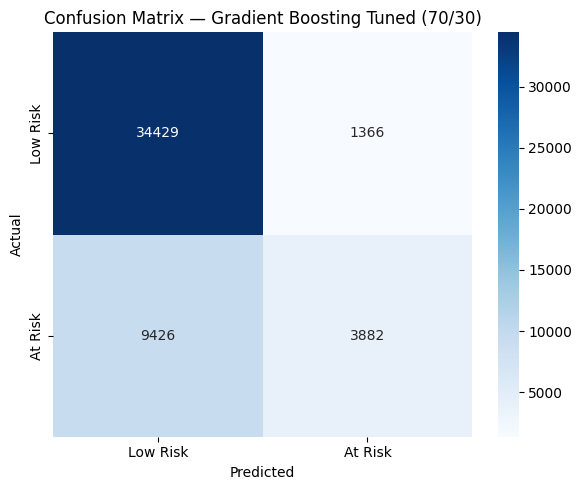

  Confusion matrix saved → cm_Gradient_Boosting_Tuned_70_30.png


In [36]:
# Evaluate tuned Gradient Boosting — both splits
res_gb_tuned_80 = evaluate_model(gb_tuned_80, X_test_80_tree, y_test_80, 'Gradient Boosting Tuned', '80/20')
res_gb_tuned_70 = evaluate_model(gb_tuned_70, X_test_70_tree, y_test_70, 'Gradient Boosting Tuned', '70/30')
results.append(res_gb_tuned_80)
results.append(res_gb_tuned_70)

In [37]:
# Gradient Boosting — Baseline vs Tuned Comparison
import pandas as pd
gb_comparison = pd.DataFrame([res_gb_80, res_gb_70, res_gb_tuned_80, res_gb_tuned_70])
print("Gradient Boosting — Baseline vs Tuned Comparison")
print("=" * 70)
print(gb_comparison.to_string(index=False))

Gradient Boosting — Baseline vs Tuned Comparison
                  Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Gradient Boosting 80/20    0.7633    0.6609       0.7463   0.7349
      Gradient Boosting 70/30    0.7672    0.6608       0.7478   0.7356
Gradient Boosting Tuned 80/20    0.7797    0.6408       0.7431   0.7386
Gradient Boosting Tuned 70/30    0.7802    0.6415       0.7436   0.7391


6. Decision Tree

In [38]:
# Train Decision Tree — 80/20
from sklearn.tree import DecisionTreeClassifier

dt_80 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
print("Training Decision Tree (80/20)...")
dt_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Decision Tree (80/20)...
Done.


In [39]:
# Train Decision Tree — 70/30
dt_70 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
print("Training Decision Tree (70/30)...")
dt_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Decision Tree (70/30)...
Done.



  Decision Tree — 80/20
  Accuracy         : 0.6887
  F1 (macro)       : 0.5937
  F1 (weighted)    : 0.6837
  ROC-AUC (binary) : 0.6021

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     23864
     At Risk       0.42      0.38      0.40      8872

    accuracy                           0.69     32736
   macro avg       0.60      0.59      0.59     32736
weighted avg       0.68      0.69      0.68     32736



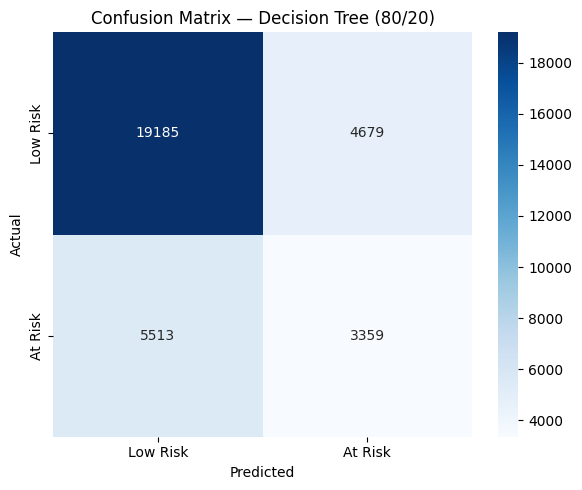

  Confusion matrix saved → cm_Decision_Tree_80_20.png

  Decision Tree — 70/30
  Accuracy         : 0.6857
  F1 (macro)       : 0.5921
  F1 (weighted)    : 0.6816
  ROC-AUC (binary) : 0.5991

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     35795
     At Risk       0.41      0.38      0.40     13308

    accuracy                           0.69     49103
   macro avg       0.59      0.59      0.59     49103
weighted avg       0.68      0.69      0.68     49103



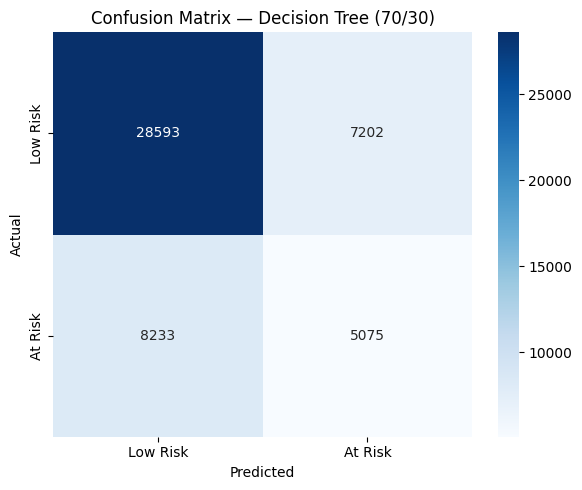

  Confusion matrix saved → cm_Decision_Tree_70_30.png


In [40]:
# Evaluate Decision Tree — both splits
res_dt_80 = evaluate_model(dt_80, X_test_80_tree, y_test_80, 'Decision Tree', '80/20')
res_dt_70 = evaluate_model(dt_70, X_test_70_tree, y_test_70, 'Decision Tree', '70/30')
results.append(res_dt_80)
results.append(res_dt_70)

In [41]:
# Hyperparameter Tuning — Decision Tree (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dist_dt = {
    'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 'class_weight': ['balanced']
}

dt_search_80 = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Decision Tree (80/20)...\n")
dt_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
dt_tuned_80 = dt_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in dt_search_80.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {dt_search_80.best_score_:.4f}")

Tuning Decision Tree (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  min_samples_split      : 2
  min_samples_leaf       : 1
  max_depth              : None
  criterion              : gini
  class_weight           : balanced

Best CV F1-macro : 0.7359


In [42]:
# Hyperparameter Tuning — Decision Tree (70/30)
dt_search_70 = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Decision Tree (70/30)...\n")
dt_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
dt_tuned_70 = dt_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in dt_search_70.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {dt_search_70.best_score_:.4f}")

Tuning Decision Tree (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  min_samples_split      : 2
  min_samples_leaf       : 1
  max_depth              : None
  criterion              : gini
  class_weight           : balanced

Best CV F1-macro : 0.7339



  Decision Tree Tuned — 80/20
  Accuracy         : 0.6887
  F1 (macro)       : 0.5937
  F1 (weighted)    : 0.6837
  ROC-AUC (binary) : 0.6021

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     23864
     At Risk       0.42      0.38      0.40      8872

    accuracy                           0.69     32736
   macro avg       0.60      0.59      0.59     32736
weighted avg       0.68      0.69      0.68     32736



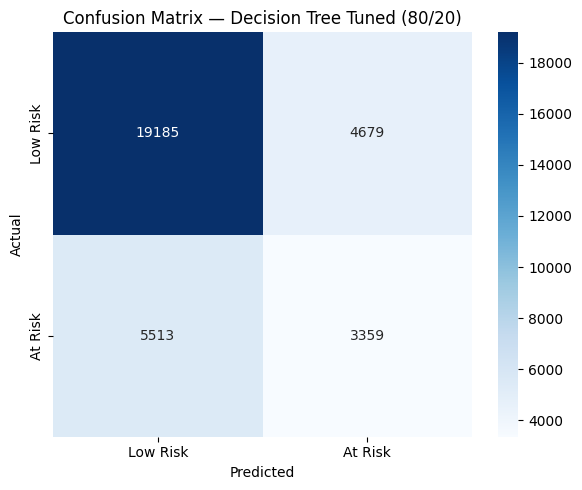

  Confusion matrix saved → cm_Decision_Tree_Tuned_80_20.png

  Decision Tree Tuned — 70/30
  Accuracy         : 0.6857
  F1 (macro)       : 0.5921
  F1 (weighted)    : 0.6816
  ROC-AUC (binary) : 0.5991

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     35795
     At Risk       0.41      0.38      0.40     13308

    accuracy                           0.69     49103
   macro avg       0.59      0.59      0.59     49103
weighted avg       0.68      0.69      0.68     49103



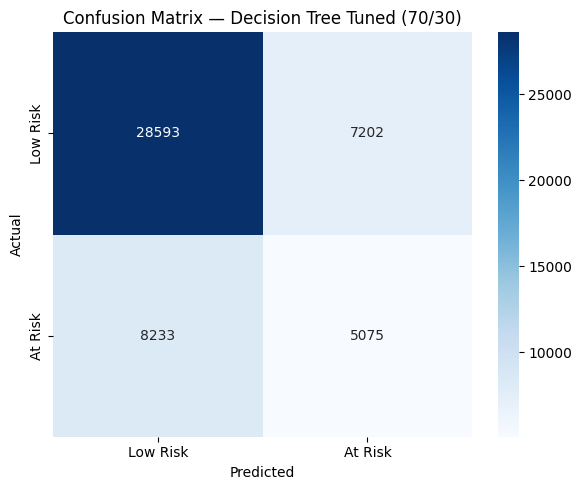

  Confusion matrix saved → cm_Decision_Tree_Tuned_70_30.png


In [43]:
# Evaluate tuned Decision Tree — both splits
res_dt_tuned_80 = evaluate_model(dt_tuned_80, X_test_80_tree, y_test_80, 'Decision Tree Tuned', '80/20')
res_dt_tuned_70 = evaluate_model(dt_tuned_70, X_test_70_tree, y_test_70, 'Decision Tree Tuned', '70/30')
results.append(res_dt_tuned_80)
results.append(res_dt_tuned_70)

In [44]:
# Decision Tree — Baseline vs Tuned Comparison
import pandas as pd
dt_comparison = pd.DataFrame([res_dt_80, res_dt_70, res_dt_tuned_80, res_dt_tuned_70])
print("Decision Tree — Baseline vs Tuned Comparison")
print("=" * 70)
print(dt_comparison.to_string(index=False))

Decision Tree — Baseline vs Tuned Comparison
              Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Decision Tree 80/20    0.6887    0.5937       0.6837   0.6021
      Decision Tree 70/30    0.6857    0.5921       0.6816   0.5991
Decision Tree Tuned 80/20    0.6887    0.5937       0.6837   0.6021
Decision Tree Tuned 70/30    0.6857    0.5921       0.6816   0.5991


7. KNN (K-Nearest Neighbors)

In [45]:
# Train KNN — 80/20
from sklearn.neighbors import KNeighborsClassifier

knn_80 = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("Training KNN (80/20)...")
knn_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training KNN (80/20)...
Done.


In [46]:
# Train KNN — 70/30
knn_70 = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("Training KNN (70/30)...")
knn_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training KNN (70/30)...
Done.



  KNN — 80/20
  Accuracy         : 0.6395
  F1 (macro)       : 0.5949
  F1 (weighted)    : 0.6564
  ROC-AUC (binary) : 0.6548

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.81      0.67      0.73     23864
     At Risk       0.39      0.57      0.46      8872

    accuracy                           0.64     32736
   macro avg       0.60      0.62      0.59     32736
weighted avg       0.69      0.64      0.66     32736



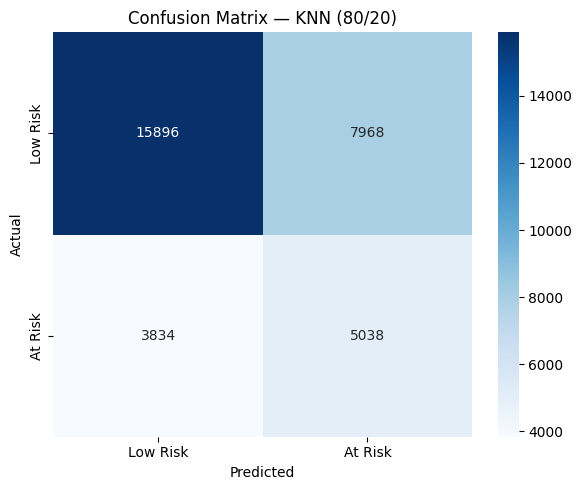

  Confusion matrix saved → cm_KNN_80_20.png

  KNN — 70/30
  Accuracy         : 0.6357
  F1 (macro)       : 0.5920
  F1 (weighted)    : 0.6531
  ROC-AUC (binary) : 0.6539

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.66      0.73     35795
     At Risk       0.38      0.57      0.46     13308

    accuracy                           0.64     49103
   macro avg       0.59      0.61      0.59     49103
weighted avg       0.69      0.64      0.65     49103



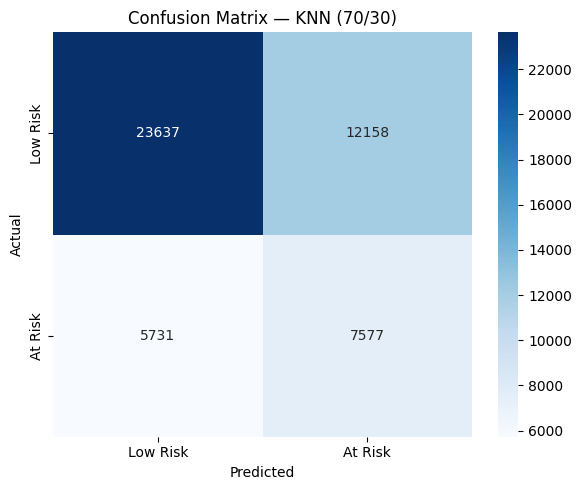

  Confusion matrix saved → cm_KNN_70_30.png


In [47]:
# Evaluate KNN — both splits
res_knn_80 = evaluate_model(knn_80, X_test_80_tree, y_test_80, 'KNN', '80/20')
res_knn_70 = evaluate_model(knn_70, X_test_70_tree, y_test_70, 'KNN', '70/30')
results.append(res_knn_80)
results.append(res_knn_70)

In [48]:
# Hyperparameter Tuning — KNN (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    'n_neighbors': [3, 5, 7, 11, 15], 'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_search_80 = RandomizedSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_distributions=param_dist_knn, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning KNN (80/20)...\n")
knn_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
knn_tuned_80 = knn_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in knn_search_80.best_params_.items():
    print(f"  {p:<15} : {v}")
print(f"\nBest CV F1-macro : {knn_search_80.best_score_:.4f}")

Tuning KNN (80/20)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters (80/20):
  weights         : distance
  n_neighbors     : 3
  metric          : manhattan

Best CV F1-macro : 0.7483


In [49]:
# Hyperparameter Tuning — KNN (70/30)
knn_search_70 = RandomizedSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_distributions=param_dist_knn, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning KNN (70/30)...\n")
knn_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
knn_tuned_70 = knn_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in knn_search_70.best_params_.items():
    print(f"  {p:<15} : {v}")
print(f"\nBest CV F1-macro : {knn_search_70.best_score_:.4f}")

Tuning KNN (70/30)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters (70/30):
  weights         : distance
  n_neighbors     : 3
  metric          : manhattan

Best CV F1-macro : 0.7533



  KNN Tuned — 80/20
  Accuracy         : 0.6876
  F1 (macro)       : 0.6077
  F1 (weighted)    : 0.6888
  ROC-AUC (binary) : 0.6358

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.78      0.78     23864
     At Risk       0.43      0.44      0.43      8872

    accuracy                           0.69     32736
   macro avg       0.61      0.61      0.61     32736
weighted avg       0.69      0.69      0.69     32736



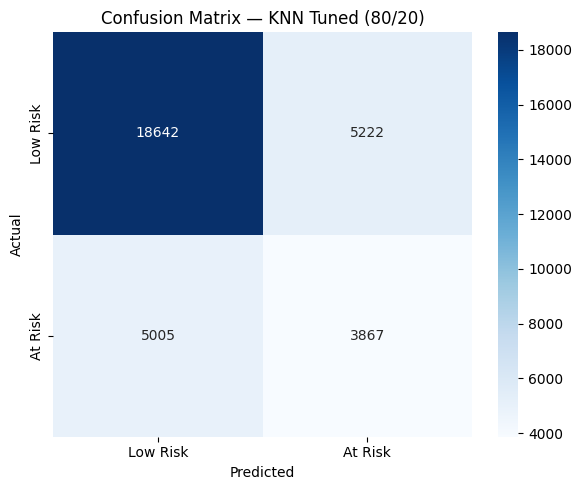

  Confusion matrix saved → cm_KNN_Tuned_80_20.png

  KNN Tuned — 70/30
  Accuracy         : 0.6856
  F1 (macro)       : 0.6056
  F1 (weighted)    : 0.6869
  ROC-AUC (binary) : 0.6337

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.78      0.78     35795
     At Risk       0.42      0.43      0.43     13308

    accuracy                           0.69     49103
   macro avg       0.60      0.61      0.61     49103
weighted avg       0.69      0.69      0.69     49103



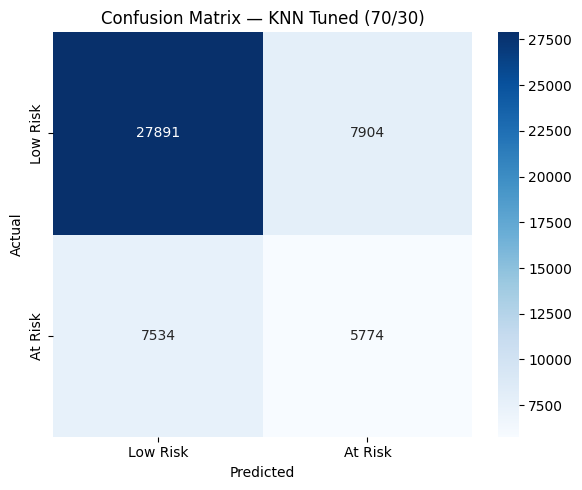

  Confusion matrix saved → cm_KNN_Tuned_70_30.png


In [50]:
# Evaluate tuned KNN — both splits
res_knn_tuned_80 = evaluate_model(knn_tuned_80, X_test_80_tree, y_test_80, 'KNN Tuned', '80/20')
res_knn_tuned_70 = evaluate_model(knn_tuned_70, X_test_70_tree, y_test_70, 'KNN Tuned', '70/30')
results.append(res_knn_tuned_80)
results.append(res_knn_tuned_70)

In [51]:
# KNN — Baseline vs Tuned Comparison
import pandas as pd
knn_comparison = pd.DataFrame([res_knn_80, res_knn_70, res_knn_tuned_80, res_knn_tuned_70])
print("KNN — Baseline vs Tuned Comparison")
print("=" * 70)
print(knn_comparison.to_string(index=False))

KNN — Baseline vs Tuned Comparison
    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      KNN 80/20    0.6395    0.5949       0.6564   0.6548
      KNN 70/30    0.6357    0.5920       0.6531   0.6539
KNN Tuned 80/20    0.6876    0.6077       0.6888   0.6358
KNN Tuned 70/30    0.6856    0.6056       0.6869   0.6337


8. Extra Trees

In [52]:
# Train Extra Trees — 80/20
from sklearn.ensemble import ExtraTreesClassifier

et_80 = ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
print("Training Extra Trees (80/20)...")
et_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Extra Trees (80/20)...
Done.


In [53]:
# Train Extra Trees — 70/30
et_70 = ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
print("Training Extra Trees (70/30)...")
et_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Extra Trees (70/30)...
Done.



  Extra Trees — 80/20
  Accuracy         : 0.7286
  F1 (macro)       : 0.6249
  F1 (weighted)    : 0.7152
  ROC-AUC (binary) : 0.6560

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     23864
     At Risk       0.50      0.37      0.43      8872

    accuracy                           0.73     32736
   macro avg       0.64      0.62      0.62     32736
weighted avg       0.71      0.73      0.72     32736



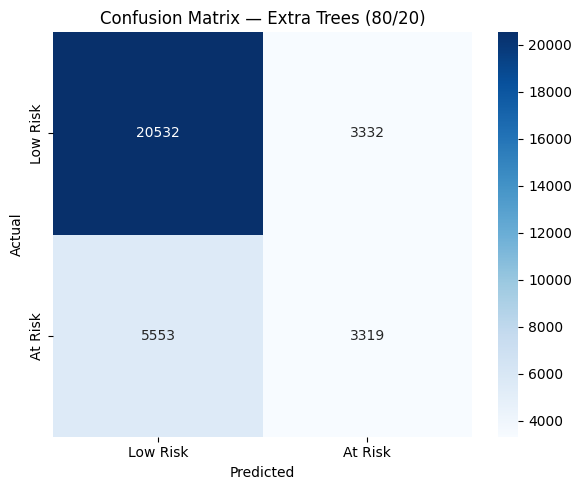

  Confusion matrix saved → cm_Extra_Trees_80_20.png

  Extra Trees — 70/30
  Accuracy         : 0.7270
  F1 (macro)       : 0.6227
  F1 (weighted)    : 0.7135
  ROC-AUC (binary) : 0.6561

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     35795
     At Risk       0.50      0.37      0.42     13308

    accuracy                           0.73     49103
   macro avg       0.64      0.62      0.62     49103
weighted avg       0.71      0.73      0.71     49103



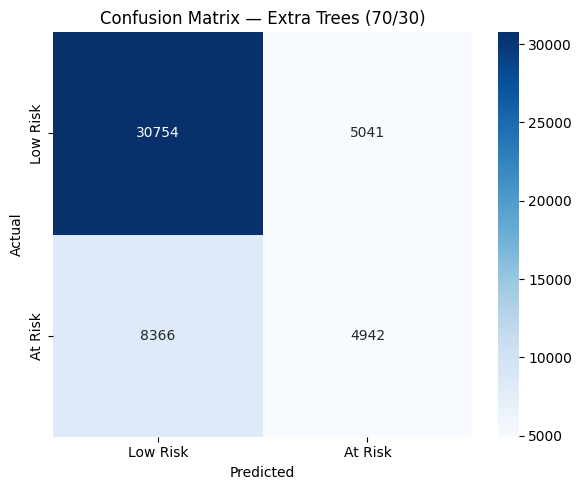

  Confusion matrix saved → cm_Extra_Trees_70_30.png


In [54]:
# Evaluate Extra Trees — both splits
res_et_80 = evaluate_model(et_80, X_test_80_tree, y_test_80, 'Extra Trees', '80/20')
res_et_70 = evaluate_model(et_70, X_test_70_tree, y_test_70, 'Extra Trees', '70/30')
results.append(res_et_80)
results.append(res_et_70)

In [55]:
# Hyperparameter Tuning — Extra Trees (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesClassifier

param_dist_et = {
    'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2'], 'class_weight': ['balanced']
}

et_search_80 = RandomizedSearchCV(
    estimator=ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_et, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Extra Trees (80/20)...\n")
et_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
et_tuned_80 = et_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in et_search_80.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {et_search_80.best_score_:.4f}")

Tuning Extra Trees (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  n_estimators           : 200
  min_samples_split      : 5
  max_features           : sqrt
  max_depth              : None
  class_weight           : balanced

Best CV F1-macro : 0.7951


In [56]:
# Hyperparameter Tuning — Extra Trees (70/30)
et_search_70 = RandomizedSearchCV(
    estimator=ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_et, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Extra Trees (70/30)...\n")
et_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
et_tuned_70 = et_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in et_search_70.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {et_search_70.best_score_:.4f}")

Tuning Extra Trees (70/30)...



Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  n_estimators           : 300
  min_samples_split      : 2
  max_features           : log2
  max_depth              : None
  class_weight           : balanced

Best CV F1-macro : 0.7979



  Extra Trees Tuned — 80/20
  Accuracy         : 0.7294
  F1 (macro)       : 0.6336
  F1 (weighted)    : 0.7194
  ROC-AUC (binary) : 0.6830

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.85      0.82     23864
     At Risk       0.50      0.40      0.45      8872

    accuracy                           0.73     32736
   macro avg       0.65      0.63      0.63     32736
weighted avg       0.71      0.73      0.72     32736



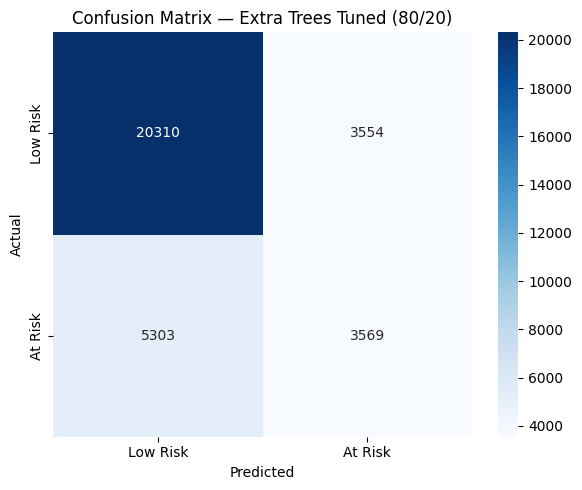

  Confusion matrix saved → cm_Extra_Trees_Tuned_80_20.png

  Extra Trees Tuned — 70/30
  Accuracy         : 0.7276
  F1 (macro)       : 0.6238
  F1 (weighted)    : 0.7143
  ROC-AUC (binary) : 0.6561

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     35795
     At Risk       0.50      0.37      0.43     13308

    accuracy                           0.73     49103
   macro avg       0.64      0.62      0.62     49103
weighted avg       0.71      0.73      0.71     49103



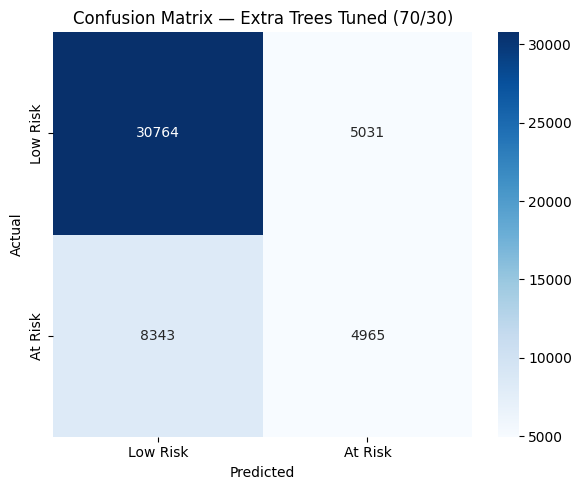

  Confusion matrix saved → cm_Extra_Trees_Tuned_70_30.png


In [57]:
# Evaluate tuned Extra Trees — both splits
res_et_tuned_80 = evaluate_model(et_tuned_80, X_test_80_tree, y_test_80, 'Extra Trees Tuned', '80/20')
res_et_tuned_70 = evaluate_model(et_tuned_70, X_test_70_tree, y_test_70, 'Extra Trees Tuned', '70/30')
results.append(res_et_tuned_80)
results.append(res_et_tuned_70)

In [58]:
# Extra Trees — Baseline vs Tuned Comparison
import pandas as pd
et_comparison = pd.DataFrame([res_et_80, res_et_70, res_et_tuned_80, res_et_tuned_70])
print("Extra Trees — Baseline vs Tuned Comparison")
print("=" * 70)
print(et_comparison.to_string(index=False))

Extra Trees — Baseline vs Tuned Comparison
            Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Extra Trees 80/20    0.7286    0.6249       0.7152   0.6560
      Extra Trees 70/30    0.7270    0.6227       0.7135   0.6561
Extra Trees Tuned 80/20    0.7294    0.6336       0.7194   0.6830
Extra Trees Tuned 70/30    0.7276    0.6238       0.7143   0.6561


9. LightGBM

In [59]:
# Train LightGBM — 80/20
from lightgbm import LGBMClassifier

lgbm_80 = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
print("Training LightGBM (80/20)...")
lgbm_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training LightGBM (80/20)...
Done.


In [60]:
# Train LightGBM — 70/30
lgbm_70 = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
print("Training LightGBM (70/30)...")
lgbm_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training LightGBM (70/30)...
Done.


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM — 80/20
  Accuracy         : 0.7788
  F1 (macro)       : 0.6477
  F1 (weighted)    : 0.7461
  ROC-AUC (binary) : 0.7397

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.95      0.86     23864
     At Risk       0.71      0.31      0.43      8872

    accuracy                           0.78     32736
   macro avg       0.75      0.63      0.65     32736
weighted avg       0.77      0.78      0.75     32736



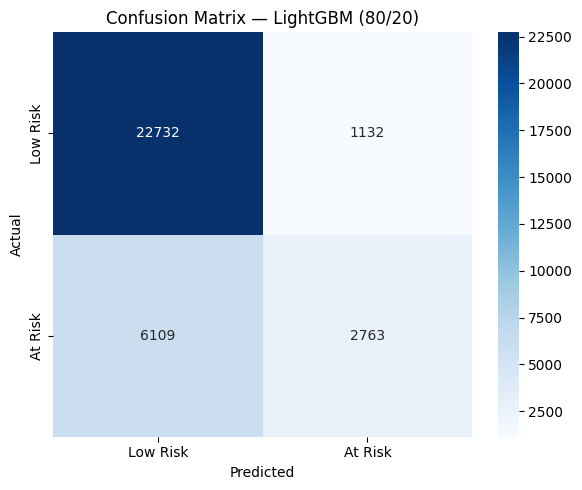

  Confusion matrix saved → cm_LightGBM_80_20.png


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM — 70/30
  Accuracy         : 0.7795
  F1 (macro)       : 0.6481
  F1 (weighted)    : 0.7466
  ROC-AUC (binary) : 0.7397

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.95      0.86     35795
     At Risk       0.71      0.31      0.43     13308

    accuracy                           0.78     49103
   macro avg       0.75      0.63      0.65     49103
weighted avg       0.77      0.78      0.75     49103



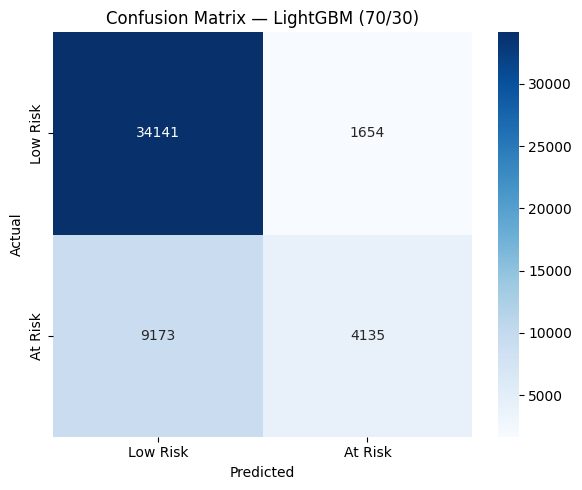

  Confusion matrix saved → cm_LightGBM_70_30.png


In [61]:
# Evaluate LightGBM — both splits
res_lgbm_80 = evaluate_model(lgbm_80, X_test_80_tree, y_test_80, 'LightGBM', '80/20')
res_lgbm_70 = evaluate_model(lgbm_70, X_test_70_tree, y_test_70, 'LightGBM', '70/30')
results.append(res_lgbm_80)
results.append(res_lgbm_70)

In [62]:
# Hyperparameter Tuning — LightGBM (80/20)
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

param_dist_lgbm = {
    'n_estimators': [100, 200, 300], 'max_depth': [-1, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3], 'num_leaves': [31, 63, 127], 'class_weight': ['balanced']
}

lgbm_search_80 = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning LightGBM (80/20)...\n")
lgbm_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
lgbm_tuned_80 = lgbm_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in lgbm_search_80.best_params_.items():
    print(f"  {p:<18} : {v}")
print(f"\nBest CV F1-macro : {lgbm_search_80.best_score_:.4f}")

Tuning LightGBM (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  num_leaves         : 31
  n_estimators       : 300
  max_depth          : -1
  learning_rate      : 0.1
  class_weight       : balanced

Best CV F1-macro : 0.7600


In [63]:
# Hyperparameter Tuning — LightGBM (70/30)
lgbm_search_70 = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning LightGBM (70/30)...\n")
lgbm_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
lgbm_tuned_70 = lgbm_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in lgbm_search_70.best_params_.items():
    print(f"  {p:<18} : {v}")
print(f"\nBest CV F1-macro : {lgbm_search_70.best_score_:.4f}")

Tuning LightGBM (70/30)...



Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  num_leaves         : 31
  n_estimators       : 300
  max_depth          : -1
  learning_rate      : 0.1
  class_weight       : balanced

Best CV F1-macro : 0.7624


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM Tuned — 80/20
  Accuracy         : 0.7790
  F1 (macro)       : 0.6426
  F1 (weighted)    : 0.7437
  ROC-AUC (binary) : 0.7388

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     23864
     At Risk       0.72      0.30      0.42      8872

    accuracy                           0.78     32736
   macro avg       0.76      0.63      0.64     32736
weighted avg       0.77      0.78      0.74     32736



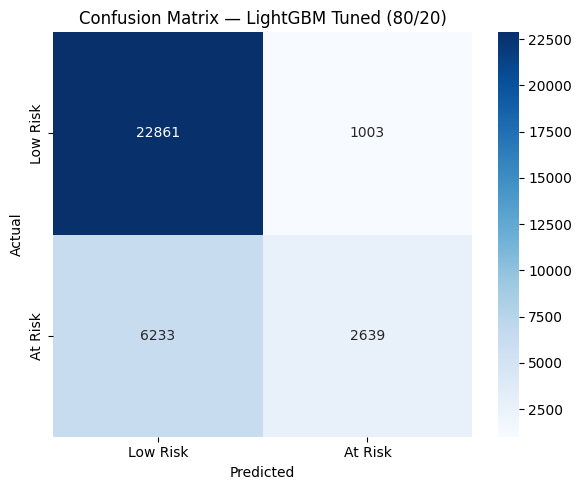

  Confusion matrix saved → cm_LightGBM_Tuned_80_20.png


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM Tuned — 70/30
  Accuracy         : 0.7786
  F1 (macro)       : 0.6427
  F1 (weighted)    : 0.7436
  ROC-AUC (binary) : 0.7380

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     35795
     At Risk       0.72      0.30      0.42     13308

    accuracy                           0.78     49103
   macro avg       0.75      0.63      0.64     49103
weighted avg       0.77      0.78      0.74     49103



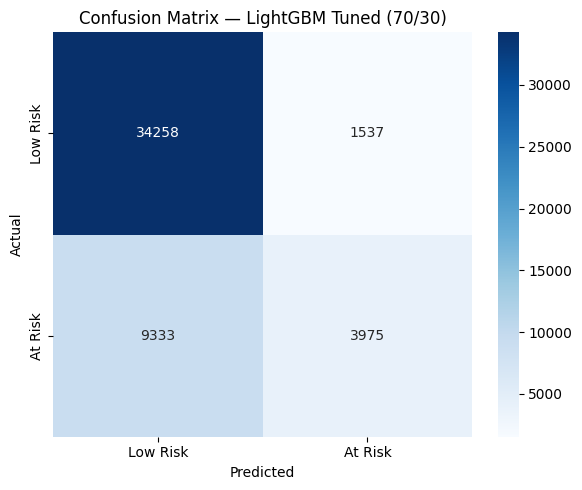

  Confusion matrix saved → cm_LightGBM_Tuned_70_30.png


In [64]:
# Evaluate tuned LightGBM — both splits
res_lgbm_tuned_80 = evaluate_model(lgbm_tuned_80, X_test_80_tree, y_test_80, 'LightGBM Tuned', '80/20')
res_lgbm_tuned_70 = evaluate_model(lgbm_tuned_70, X_test_70_tree, y_test_70, 'LightGBM Tuned', '70/30')
results.append(res_lgbm_tuned_80)
results.append(res_lgbm_tuned_70)

In [65]:
# LightGBM — Baseline vs Tuned Comparison
import pandas as pd
lgbm_comparison = pd.DataFrame([res_lgbm_80, res_lgbm_70, res_lgbm_tuned_80, res_lgbm_tuned_70])
print("LightGBM — Baseline vs Tuned Comparison")
print("=" * 70)
print(lgbm_comparison.to_string(index=False))

LightGBM — Baseline vs Tuned Comparison
         Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      LightGBM 80/20    0.7788    0.6477       0.7461   0.7397
      LightGBM 70/30    0.7795    0.6481       0.7466   0.7397
LightGBM Tuned 80/20    0.7790    0.6426       0.7437   0.7388
LightGBM Tuned 70/30    0.7786    0.6427       0.7436   0.7380


10. Master Results — All Models Comparison

In [66]:
# All Models — Master Performance Comparison
import pandas as pd

results_df = pd.DataFrame(results)

print("All Models — Master Performance Comparison")
print("=" * 75)
print(results_df.to_string(index=False))

print("\n\nSorted by F1-macro (descending):")
print("=" * 75)
print(results_df.sort_values('F1_macro', ascending=False).to_string(index=False))

All Models — Master Performance Comparison
                    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
            Random Forest 80/20    0.7283    0.6288       0.7168   0.6829
            Random Forest 70/30    0.7269    0.6273       0.7156   0.6839
      Random Forest Tuned 80/20    0.7307    0.6410       0.7232   0.7036
      Random Forest Tuned 70/30    0.7289    0.6391       0.7216   0.7030
                  XGBoost 80/20    0.7786    0.6421       0.7433   0.7359
                  XGBoost 70/30    0.7780    0.6428       0.7435   0.7359
            XGBoost Tuned 80/20    0.7792    0.6439       0.7444   0.7385
            XGBoost Tuned 70/30    0.7803    0.6446       0.7452   0.7380
      Logistic Regression 80/20    0.6616    0.6275       0.6791   0.7336
      Logistic Regression 70/30    0.6614    0.6266       0.6788   0.7334
Logistic Regression Tuned 80/20    0.6612    0.6270       0.6787   0.7339
Logistic Regression Tuned 70/30    0.6615    0.6266       0.6789   0.

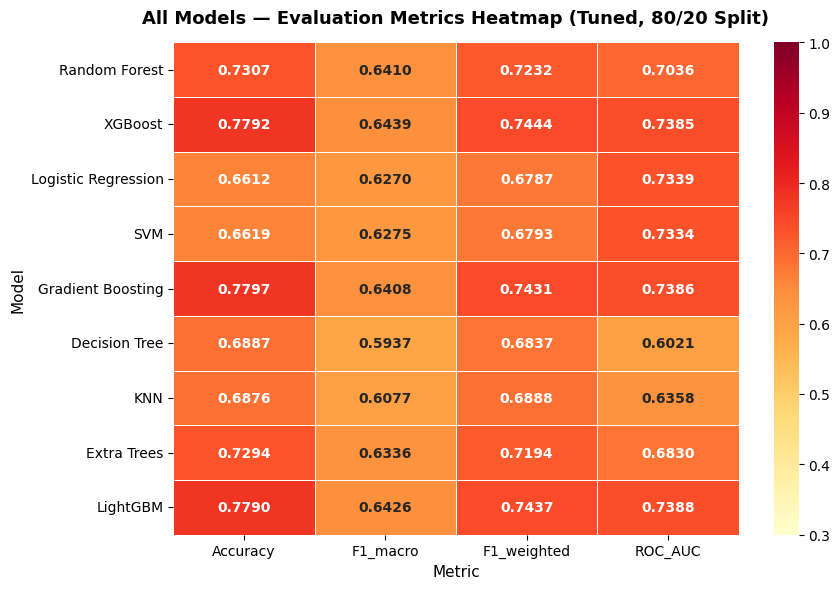

Saved → master_heatmap.png


In [67]:
# Metric Heatmap — tuned models, 80/20 split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'F1_macro', 'F1_weighted', 'ROC_AUC']

tuned_80 = results_df[
    results_df['Model'].str.contains('Tuned') & (results_df['Split'] == '80/20')
].copy()
tuned_80['Model'] = tuned_80['Model'].str.replace(' Tuned', '', regex=False)
heatmap_data = tuned_80.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
    vmin=0.30, vmax=1.0, linewidths=0.6,
    annot_kws={'size': 10, 'weight': 'bold'}, ax=ax
)
ax.set_title('All Models — Evaluation Metrics Heatmap (Tuned, 80/20 Split)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.savefig('master_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → master_heatmap.png")

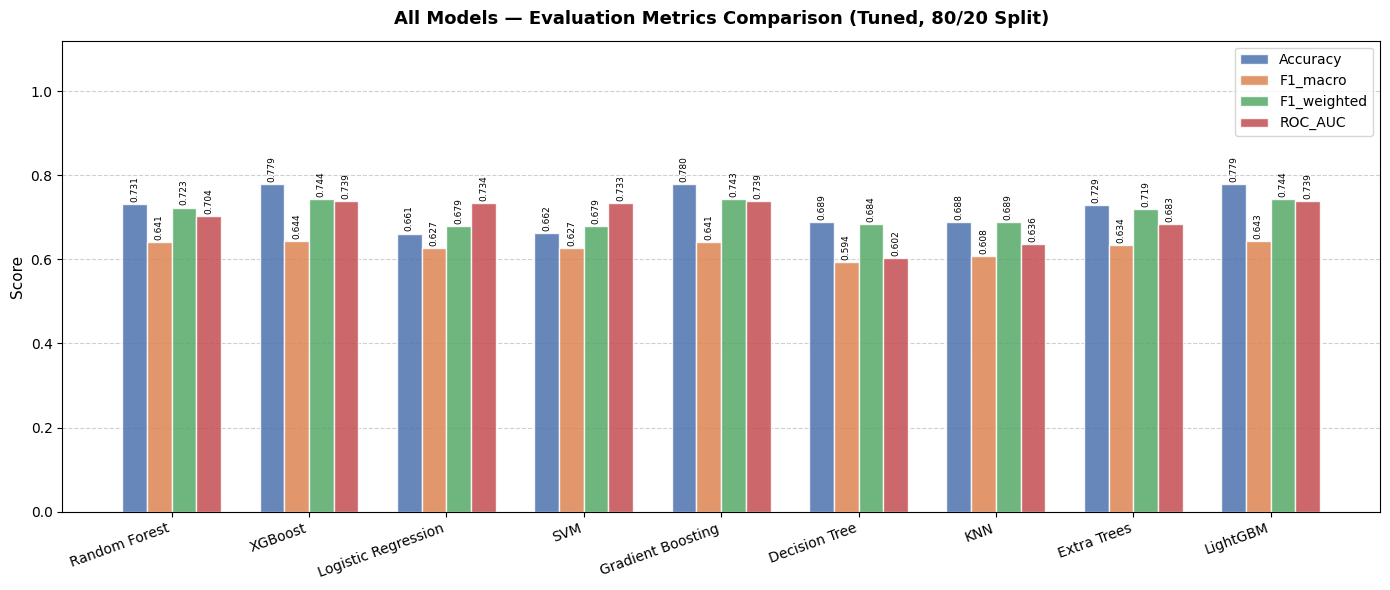

Saved → master_bar_chart.png


In [68]:
# Grouped Bar Chart — all 4 metrics for all tuned models (80/20 split)
import numpy as np
import matplotlib.pyplot as plt

models   = heatmap_data.index.tolist()
metrics  = ['Accuracy', 'F1_macro', 'F1_weighted', 'ROC_AUC']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

x      = np.arange(len(models))
width  = 0.18
fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = heatmap_data[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Models — Evaluation Metrics Comparison (Tuned, 80/20 Split)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('master_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → master_bar_chart.png")

## 11. Save Models for System Deployment

In [69]:
import joblib
import os

# Save top 4 models
joblib.dump(gb_80,       'model_gradient_boosting.pkl')
joblib.dump(xgb_80,      'model_xgboost.pkl')
joblib.dump(lgbm_80,     'model_lightgbm.pkl')
joblib.dump(rf_tuned_80, 'model_random_forest.pkl')

# Save preprocessor — required to transform user input before prediction
joblib.dump(preprocessor_tree, 'preprocessor_tree.pkl')

# Confirm files saved
saved_files = [
    'model_gradient_boosting.pkl',
    'model_xgboost.pkl',
    'model_lightgbm.pkl',
    'model_random_forest.pkl',
    'preprocessor_tree.pkl'
]

print("Models saved successfully:")
for f in saved_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:<40} ({size_kb:.1f} KB)")

Models saved successfully:
  model_gradient_boosting.pkl              (474.6 KB)
  model_xgboost.pkl                        (339.5 KB)
  model_lightgbm.pkl                       (347.2 KB)
  model_random_forest.pkl                  (780151.2 KB)
  preprocessor_tree.pkl                    (6.0 KB)
